<a href="https://colab.research.google.com/github/Alina1-10/MH_Alina_Gubnitska_3-10/blob/main/%D0%9B%D0%A03_%D0%93%D1%83%D0%B1%D0%BD%D0%B8%D1%86%D1%8C%D0%BA%D0%B0_3_10__ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 3. Машинне навчання
## Регресія: прогнозування вартості нерухомості

**Мета роботи:** виконати первинний аналіз даних, побудувати кілька моделей регресії, оцінити їхню якість та виконати підбір гіперпараметрів для моделі Random Forest.

### Датасет
Можна використати один із двох способів завантаження даних:

1. Завантажити файл з Google Drive:
https://drive.google.com/file/d/1u_-3X05st6uvrgQB1qNLyE8a7QjTJjvd/view?usp=sharing

2. Завантажити датасет з Kaggle:
https://www.kaggle.com/datasets/prokshitha/home-value-insights

> Посилання та вміст датасету на зовнішніх платформах можуть змінюватися.

## 1. Імпорт бібліотек
Імпортуйте бібліотеки, необхідні для роботи з даними, візуалізації та числових обчислень.

In [45]:
# Ваш код:
# Імпортуйте pandas, numpy, matplotlib.pyplot, seaborn та інші потрібні бібліотеки.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## 2. Завантаження даних
Оберіть **один** зі способів завантаження датасету.

### Варіант 1. Завантаження файлу з комп’ютера
Завантажте CSV-файл у середовище Colab.

In [46]:
# Ваш код:
# Завантажте файл і збережіть дані у DataFrame `df`.

from google.colab import files
import pandas as pd
uploaded = files.upload()




Saving house_price_regression_dataset.csv to house_price_regression_dataset (4).csv


In [47]:
df = pd.read_csv('house_price_regression_dataset.csv')
display(df)

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


### Варіант 2. Завантаження датасету з Kaggle
Завантажте датасет безпосередньо з Kaggle та прочитайте CSV-файл у DataFrame `df`.

**обрала завантажити датасет першим варіантом**

## 3. Опис ознак датасету

- **Square_Footage** — загальна житлова площа будинку.
- **Num_Bedrooms** — кількість спалень.
- **Num_Bathrooms** — кількість ванних кімнат.
- **Year_Built** — рік побудови будинку.
- **Lot_Size** — розмір земельної ділянки.
- **Garage_Size** — розмір гаража або кількість паркомісць.
- **Neighborhood_Quality** — оцінка якості району.
- **House_Price** — ціна будинку, цільова змінна.

## 4. Первинний аналіз даних

### Завдання 1. Перегляд даних
Виведіть перші рядки датасету та перегляньте його структуру.

In [48]:
# Ваш код:
# Виведіть кілька перших рядків та загальну інформацію про DataFrame.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


### Завдання 2. Перевірка дублікатів
Визначте кількість дубльованих рядків.

In [49]:
# Ваш код:
# Порахуйте кількість дублікатів.

df.duplicated().sum()

np.int64(0)

### Завдання 3. Перевірка пропущених значень
Визначте кількість пропущених значень у кожному стовпці.

In [50]:
# Ваш код:
# Виведіть кількість пропусків для кожної ознаки.

df.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


### Завдання 4. Описова статистика
Виведіть основні статистичні характеристики числових ознак.

In [51]:
# Ваш код:
# Отримайте описову статистику датасету.

df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


## 5. Аналіз окремих ознак

### Завдання 5. Ознака `Neighborhood_Quality`
Виведіть частоти значень ознаки `Neighborhood_Quality`.

In [52]:
# Ваш код:
# Порахуйте кількість спостережень для кожного значення `Neighborhood_Quality`.
df['Neighborhood_Quality'].value_counts()


,count
Neighborhood_Quality,
10,123
5,109
2,105
7,102
6,101
4,99
8,97
1,91
9,88


### Завдання 6. Візуалізація `Neighborhood_Quality`
Побудуйте діаграму розподілу значень цієї ознаки.

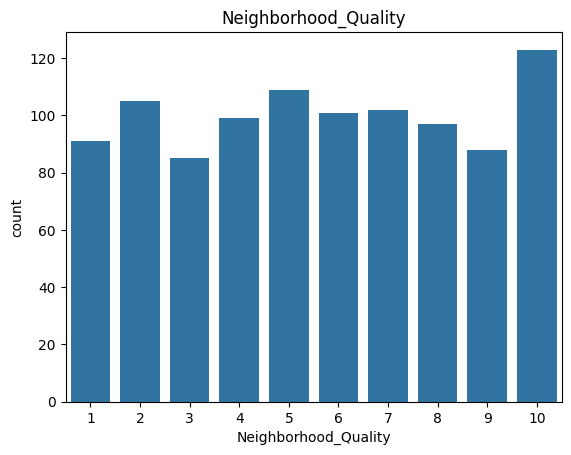

In [53]:
# Ваш код:
# Побудуйте countplot або іншу відповідну діаграму.
sns.countplot(x='Neighborhood_Quality', data=df)
plt.title('Neighborhood_Quality')
plt.show()



### Завдання 7. Ознака `Num_Bathrooms`
Виведіть частоти значень кількості ванних кімнат.

In [54]:
# Ваш код:
# Порахуйте кількість спостережень для кожного значення `Num_Bathrooms`.

df['Num_Bathrooms'].value_counts()



,count
Num_Bathrooms,
1,350
2,327
3,323


### Завдання 8. Візуалізація `Num_Bathrooms`
Побудуйте діаграму розподілу кількості ванних кімнат.

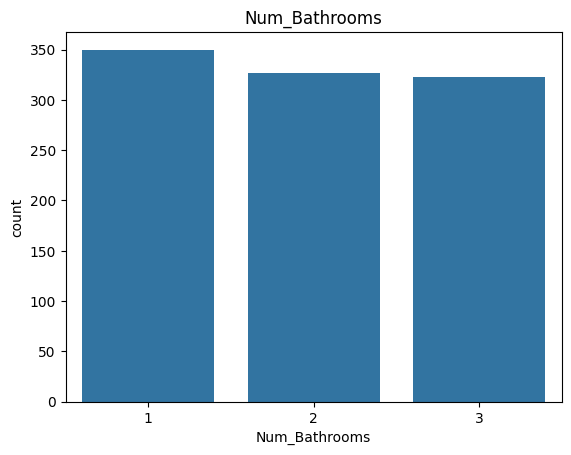

In [55]:
# Ваш код:
# Побудуйте відповідну діаграму.

sns.countplot(x='Num_Bathrooms', data=df)
plt.title('Num_Bathrooms')
plt.show()



### Додаткове завдання
За потреби побудуйте попарні графіки числових ознак і коротко проаналізуйте можливі залежності.

In [56]:
# Ваш код:
# Побудуйте pairplot або іншу попарну візуалізацію.
df['Num_Bedrooms'].value_counts()




,count
Num_Bedrooms,
2,215
5,205
1,201
4,197
3,182


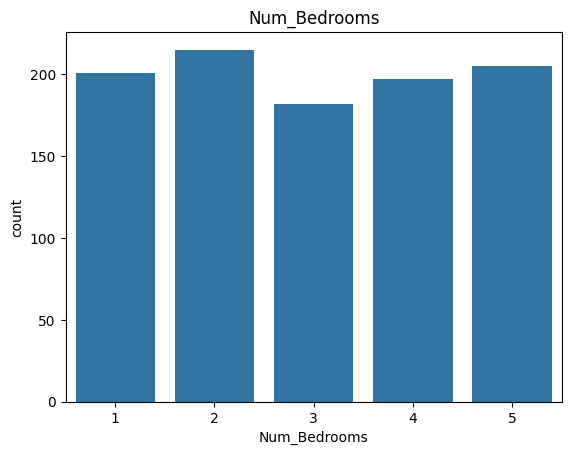

In [57]:
sns.countplot(x='Num_Bedrooms', data=df)
plt.title('Num_Bedrooms')
plt.show()

## 6. Кореляційний аналіз

### Завдання 9. Матриця кореляції
Побудуйте кореляційну матрицю для числових ознак та відобразіть її у вигляді теплової карти.

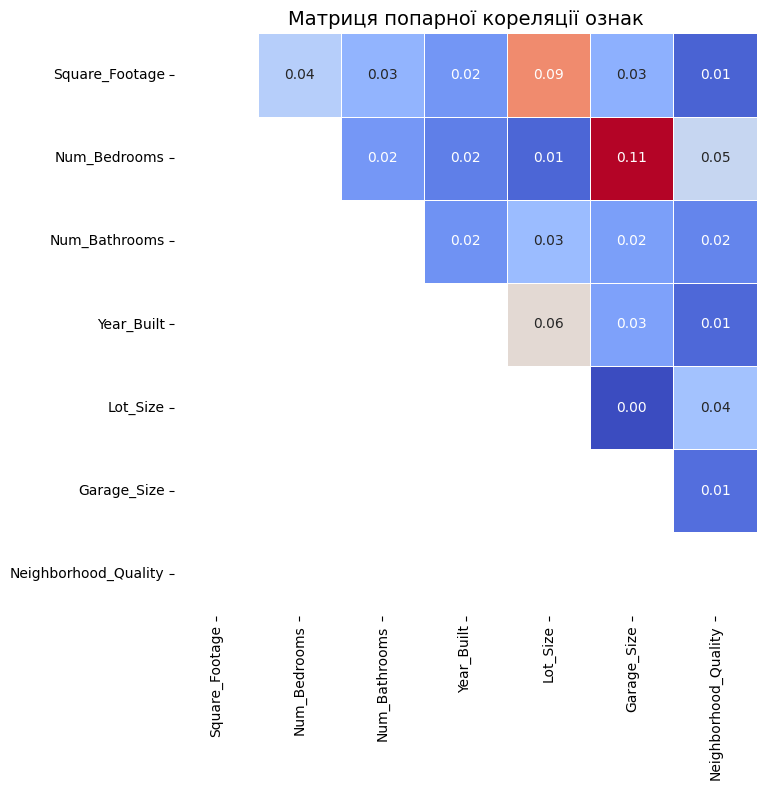

In [58]:
# Ваш код:
# Обчисліть кореляційну матрицю та побудуйте heatmap.

mtx = df.drop('House_Price', axis=1).corr(numeric_only=True).abs()

fig, ax = plt.subplots(figsize=(8, 8))

sns.heatmap(
    mtx,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    mask=np.tril(np.ones_like(mtx, dtype=bool)),
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Матриця попарної кореляції ознак", fontsize=14)
plt.tight_layout()
plt.show()



### Завдання 10. Кореляція з цільовою змінною
Виведіть кореляцію кожної ознаки з `House_Price`, відсортувавши значення за спаданням.

In [59]:
# Ваш код:
# Виведіть кореляції ознак із `House_Price`.

correlation_with_House_Price = df.corr(numeric_only=True)['House_Price'].sort_values(ascending=False)
correlation_with_House_Price


,House_Price
House_Price,1.000000
Square_Footage,0.991261
Lot_Size,0.160412
Garage_Size,0.052133
Year_Built,0.051967
Num_Bedrooms,0.014633
Num_Bathrooms,-0.001862
Neighborhood_Quality,-0.007770


## 7. Побудова моделей регресії

### Завдання 11. Імпорт інструментів Scikit-learn
Імпортуйте засоби для:
- поділу вибірки;
- масштабування ознак;
- побудови Linear Regression, Ridge, Lasso, Random Forest та Gradient Boosting;
- створення Pipeline;
- обчислення R², MAE та MSE.

In [60]:
# Ваш код:
# Імпортуйте необхідні класи та функції зі scikit-learn.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline




### Завдання 12. Формування `X` і `y`
Відокремте ознаки від цільової змінної `House_Price`.

In [61]:
# Ваш код:
# Створіть `X` та `y`.

X = df.drop(columns=['House_Price'])
y = df['House_Price']



### Завдання 13. Поділ даних
Поділіть дані на навчальну і тестову вибірки у співвідношенні 80/20. Для відтворюваності використайте `random_state=42`.

In [62]:
# Ваш код:
# Створіть `X_train`, `X_test`, `y_train`, `y_test`.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



### Завдання 14. Створення моделей
Створіть п’ять моделей:
1. Linear Regression;
2. Ridge;
3. Lasso;
4. Random Forest Regressor;
5. Gradient Boosting Regressor.

Для лінійних моделей використайте `Pipeline` зі `StandardScaler`. Для деревоподібних моделей масштабування не потрібне.

In [63]:
# Ваш код:
# Створіть словник або іншу структуру з п’ятьма моделями.


models = {
    "LinearRegression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),

    "Ridge": Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),

    "Lasso": Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.1, max_iter=10000))
    ]),

    "Random Forest": RandomForestRegressor(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}


### Завдання 15. Навчання та оцінювання моделей
Для кожної моделі:
- виконайте навчання на тренувальній вибірці;
- отримайте прогноз для тестової вибірки;
- обчисліть `R²`, `MAE`, `MSE`;
- збережіть результати для подальшого порівняння.

In [64]:
# Ваш код:
# Навчіть усі моделі, отримайте прогнози та метрики на тестовій вибірці.

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)


    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mape=mean_absolute_percentage_error(y_test, y_pred)

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "R²": r2,
        "MAE": mae,
        "MSE": mse,
        "MAPE": mape
    }

    print(
        f"[{name}] "
        f"R²: {r2:.6f} | "
        f"MAE: {mae:.3f} | "
        f"MSE: {mse:.3f} |"
        f"MAPE: {mape:.3f}"
    )



[LinearRegression] R²: 0.998426 | MAE: 8174.584 | MSE: 101434798.506 |MAPE: 0.017
[Ridge] R²: 0.998410 | MAE: 8241.587 | MSE: 102480990.009 |MAPE: 0.017
[Lasso] R²: 0.998426 | MAE: 8174.607 | MSE: 101435077.051 |MAPE: 0.017
[Random Forest] R²: 0.993886 | MAE: 16114.290 | MSE: 394131747.446 |MAPE: 0.032
[Gradient Boosting] R²: 0.996510 | MAE: 12305.218 | MSE: 224965597.845 |MAPE: 0.025


### Завдання 16. Графічне порівняння прогнозів
Для кожної моделі побудуйте графік **фактичні значення vs прогнозовані значення**. Додайте лінію ідеального прогнозу.

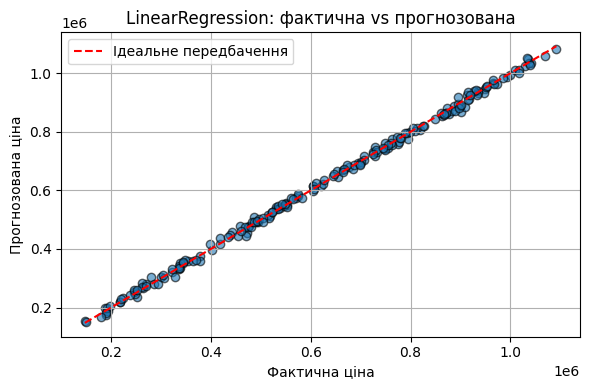

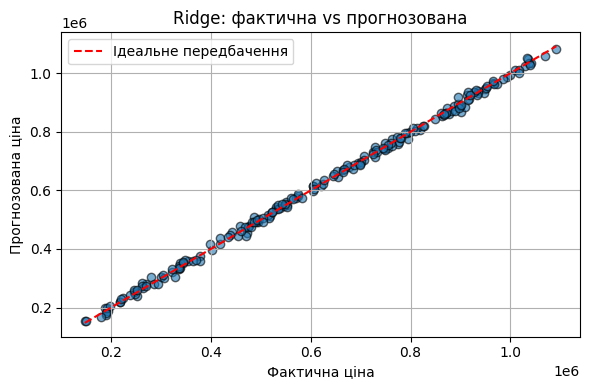

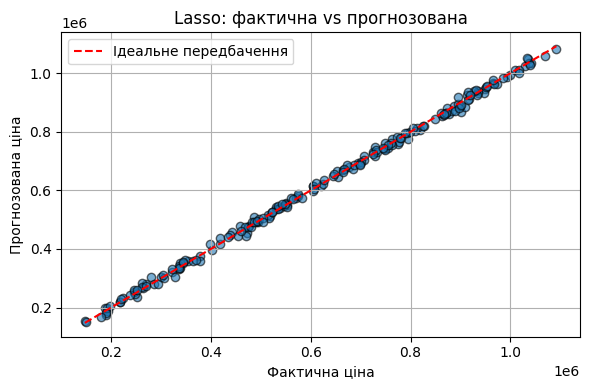

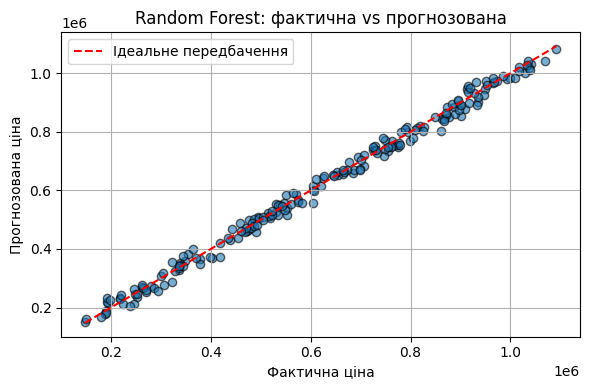

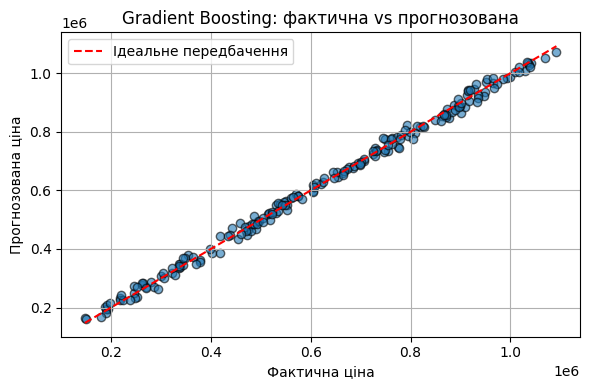

In [65]:
# Ваш код:
# Побудуйте окремий графік для кожної моделі.

for name, res in results.items():
    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, res["y_pred"], alpha=0.6, edgecolors='k')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', label='Ідеальне передбачення')

    plt.xlabel("Фактична ціна")
    plt.ylabel("Прогнозована ціна")
    plt.title(f"{name}: фактична vs прогнозована")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



## 8. Підбір гіперпараметрів Random Forest

### Завдання 17. GridSearchCV
Виконайте підбір оптимальних параметрів для `RandomForestRegressor` за допомогою `GridSearchCV`.

Дослідіть щонайменше такі параметри:
- `n_estimators`;
- `max_features`;
- `max_depth`;
- `min_samples_split`.

Використайте крос-валідацію та метрику `R²`.

In [66]:
# Ваш код:
# Створіть сітку параметрів, GridSearchCV і знайдіть найкращі параметри.

from sklearn.model_selection import GridSearchCV

param_rf = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

rf_reg_gs = RandomForestRegressor(random_state=42)

rf_search = GridSearchCV(
    estimator=rf_reg_gs,
    param_grid=param_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf_params = rf_search.best_params_

print("Найкращі параметри:")
print(best_rf_params)



Найкращі параметри:
{'max_depth': None, 'max_features': None, 'min_samples_split': 2, 'n_estimators': 200}


### Завдання 18. Оптимізована модель Random Forest
Створіть нову модель з найкращими параметрами, навчіть її та обчисліть `R²`, `MAE`, `MSE` на тестовій вибірці.

In [67]:
# Ваш код:
# Навчіть оптимізований Random Forest та обчисліть метрики.

rf_optimal = RandomForestRegressor(
    **best_rf_params,
    random_state=42
)

rf_optimal.fit(X_train, y_train)

y_pred_rf_optimal = rf_optimal.predict(X_test)

rf_mse = mean_squared_error(y_test, y_pred_rf_optimal)
rf_mae = mean_absolute_error(y_test, y_pred_rf_optimal)
rf_r2 = r2_score(y_test, y_pred_rf_optimal)
rf_mape = mean_absolute_percentage_error(y_test, y_pred_rf_optimal)

### Завдання 19. Порівняння Random Forest до і після оптимізації
Порівняйте значення `R²`, `MAE` і `MSE` для базової та оптимізованої моделей.

In [68]:
# Ваш код:
# Виведіть результати двох моделей у зручному для порівняння вигляді.

print("Random Forest до оптимізації:")
print("R²:", results["Random Forest"]["R²"])
print("MAE:", results["Random Forest"]["MAE"])
print("MSE:", results["Random Forest"]["MSE"])
print("MAPE:", results["Random Forest"]["MAPE"])

print("\nRandom Forest після оптимізації:")
print("R²:", rf_r2)
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("MAPE:", rf_mape)



Random Forest до оптимізації:
R²: 0.9938855300068556
MAE: 16114.289643937647
MSE: 394131747.44603425
MAPE: 0.03242651923455948

Random Forest після оптимізації:
R²: 0.9939926162295505
MAE: 16035.16807954079
MSE: 387229091.9214415
MAPE: 0.03230560862939432


### Завдання 20. Аналіз оптимізації
Зробіть короткий висновок:
- чи покращилася якість моделі після підбору параметрів;
- які метрики змінилися;
- чи доцільно використовувати оптимізовану модель.

**Ваш висновок:**

## 9. Аналіз прогнозів лінійної регресії

### Завдання 21. Таблиця прогнозів
Для моделі Linear Regression створіть таблицю з трьома стовпцями:
- фактична ціна;
- прогнозована ціна;
- похибка у відсотках.

Виведіть 10 випадкових рядків.

In [69]:
# Ваш код:
# Сформуйте DataFrame з фактичними та прогнозованими значеннями і розрахуйте похибку у %.

linreg_pred = results['LinearRegression']['y_pred']

comparison_df = pd.DataFrame({
    "Фактична ціна": y_test.values,
    "Передбачена ціна": linreg_pred,
})
comparison_df["Похибка, %"] = (np.abs(comparison_df["Передбачена ціна"] - comparison_df["Фактична ціна"])/comparison_df["Фактична ціна"])*100
sample = comparison_df.sample(10, random_state=42)
print(sample.round(2))



     Фактична ціна  Передбачена ціна  Похибка, %
95      1068538.11        1059729.02        0.82
15       194353.74         187868.55        3.34
30       270230.64         279715.82        3.51
158      986006.86         981949.27        0.41
128      953339.73         957382.95        0.42
115      914555.75         909764.27        0.52
69       746167.73         742469.14        0.50
170      646766.29         654445.55        1.19
174      523323.07         524605.44        0.25
45      1008539.16        1011343.64        0.28


## 10. Висновки
Сформулюйте загальний висновок за результатами лабораторної роботи. Вкажіть:

1. Які моделі було побудовано.
2. Яка модель показала найкращі значення метрик.
3. Як вплинув підбір гіперпараметрів Random Forest.
4. Наскільки точними є прогнози на тестовій вибірці.
5. Які фактори можуть впливати на якість прогнозування ціни нерухомості.

**Загальний висновок:**

Під час виконання лабораторної роботи було розроблено та проаналізовано низку моделей машинного навчання для оцінки вартості житла, зокрема: Linear Regression, Ridge, Lasso, Random Forest та Gradient Boosting. Для об'єктивного порівняння точності отриманих результатів застосовувалися метрики $R^2$, MAE, MSE та MAPE.


Аналіз показав, що найкращі результати продемонструвала модель, яка досягла максимального показника детермінації $R^2$ та мінімального рівня помилок за метриками MAE, MSE й MAPE. Це підтверджує її високу адаптивність до тестової вибірки та вищу точність у передбаченні цін на нерухомість порівняно з іншими алгоритмами.

Для алгоритму Random Forest було додатково проведено оптимізацію гіперпараметрів із використанням інструменту GridSearchCV. Налаштування параметрів дало змогу підвищити якість прогнозування відносно базової версії моделі, що підкреслює важливість етапу тюнінгу для досягнення кращих результатів.

Передбачення на тестовому наборі даних виявилися високоефективними, що підтверджується розрахованими коефіцієнтами $R^2$ та низькими значеннями помилок. При цьому підсумкова точність суттєво залежить від структури та якості вхідної інформації. На фінальну вартість об'єкта впливають такі фактори, як загальна площа будинку та прибудинкової території, число спалень і санвузлів, рік зведення, наявність гаража, якість інфраструктури району тощо.